# <font color="#0b486b">  FIT5215: Deep Learning (2026)</font>
***

Faculty of Information Technology, Monash University, Australia
***

## <font color="#0b486b">Part 3: Convolutional Neural Networks and Image Classification</font>



The third part of this assignment is to demonstrate your basis knowledge in deep learning that you have acquired from the lectures and tutorials materials. Most of the contents in this assignment are drawn from **the tutorials covered from weeks 3 to 6**. Going through these materials before attempting this assignment is highly recommended.

**The dataset used for this part is a specific dataset for this unit consisting of approximately $10,000$ images of $20$ classes of Animals, each of which has approximately 500 images. You can download the dataset at [download here](https://drive.google.com/file/d/1aEkxNWaD02Z8ZNvZzeMefUoY97C-3wTG/view?usp=drive_link) if you want to do your assignment on your machine.**


In [1]:
import os
import requests
import tarfile
import time
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torchvision.models as models
import torch.nn as nn
import torch
import PIL.Image
import pathlib
from torchsummary import summary
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

# check if CUDA is available
train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(1234)

CUDA is available!  Training on GPU ...


Download the dataset to the folder of this Google Colab.

In [2]:
# !gdown --fuzzy https://drive.google.com/file/d/10Y65ykpja1t6UWt3imPPbZkqhe0kOPL9/view?usp=sharing # new url v1
#!gdown --fuzzy https://drive.google.com/file/d/1uc7uQ5myz7k74ZO460Q04B35_GekQeGi/view?usp=sharing # new url v2

# !pip install -q --upgrade gdown
# !gdown "https://drive.google.com/uc?id=10Y65ykpja1t6UWt3imPPbZkqhe0kOPL9" -O Animals_Dataset_v1.zip

We unzip the dataset to the folder.

In [3]:
# !unzip -q Animals_Dataset_v1.zip
# !unzip -q Animals_Dataset_v2.zip
# !unzip -q Animals_Dataset.zip

In [4]:
data_dir = "./FIT5215_Dataset"

# We resize the images to [3,64,64]
transform = transforms.Compose([transforms.Resize((64,64)),  #resises the image so it can be perfect for our model.
                                      transforms.RandomHorizontalFlip(), # FLips the image w.r.t horizontal axis
                                      #transforms.RandomRotation(4),     #Rotates the image to a specified angel
                                      #transforms.RandomAffine(0, shear=10, scale=(0.8,1.2)), #Performs actions like zooms, change shear angles.
                                      transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Set the color params
                                      transforms.ToTensor(), # convert the image to tensor so that it can work with torch
                                      transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # Normalize the images, each R,G,B value is normalized with mean=0.5 and std=0.5
                                      ])


# Load the dataset using torchvision.datasets.ImageFolder and apply transformations
dataset = datasets.ImageFolder(data_dir, transform=transform)

# Split the dataset into training and validation sets
train_size = int(0.9 * len(dataset))
valid_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, valid_size])

# Example of DataLoader creation for training and validation
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Number of instance in train_set: %s" % len(train_dataset))
print("Number of instance in val_set: %s" % len(val_dataset))

Number of instance in train_set: 8519
Number of instance in val_set: 947


In [5]:
class_names = ['bird', 'bottle', 'bread', 'butterfly', 'cake', 'cat', 'chicken', 'cow', 'dog', 'duck',
                  'elephant', 'fish', 'handgun', 'horse', 'lion', 'lipstick', 'seal', 'snake', 'spider', 'vase']

In [6]:
# obtain one batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy() # convert images to numpy for display

In [7]:
import math

def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    plt.imshow(np.transpose(img, (1, 2, 0)))  # convert from Tensor image

def visualize_data(images, categories, images_per_row = 8):
    class_names = ['bird', 'bottle', 'bread', 'butterfly', 'cake', 'cat', 'chicken', 'cow', 'dog', 'duck',
                  'elephant', 'fish', 'handgun', 'horse', 'lion', 'lipstick', 'seal', 'snake', 'spider', 'vase']
    n_images = len(images)
    n_rows = math.ceil(float(n_images)/images_per_row)
    fig = plt.figure(figsize=(1.5*images_per_row, 1.5*n_rows))
    fig.patch.set_facecolor('white')
    for i in range(n_images):
        plt.subplot(n_rows, images_per_row, i+1)
        plt.xticks([])
        plt.yticks([])
        imshow(images[i])
        class_index = categories[i]
        plt.xlabel(class_names[class_index])
    plt.show()

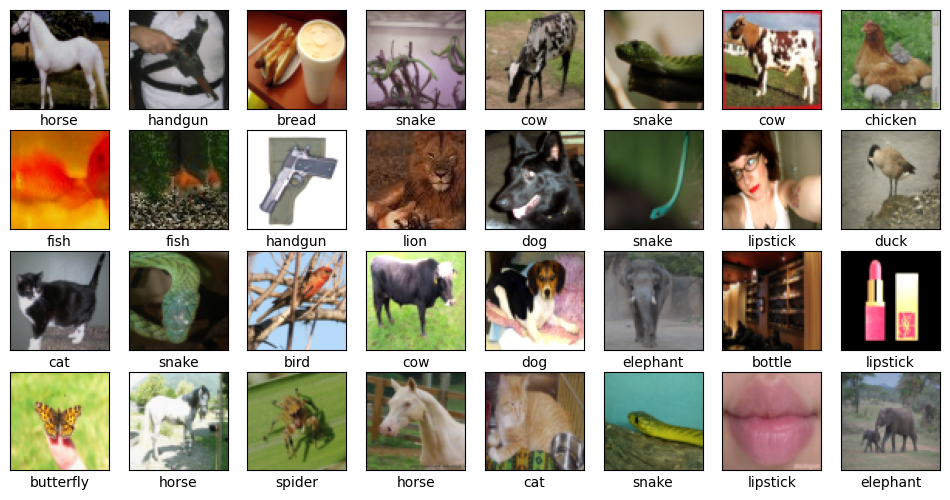

In [8]:
visualize_data(images, labels)

**For questions 3.1 to 3.5, you'll need to write your own model in a way that makes it easy for you to experiment with different architectures and parameters. The goal is to be able to pass the parameters to initialize a new instance of `YourModel` to build different network architectures with different parameters. Below are descriptions of some parameters for `YourModel`:**

1. `Block confirguration`: Our network consists of many blocks. Each block has the pattern `[conv, batch norm, activation, conv, batch norm, activation, max pool, dropout]`. All convolutional layers have filter size $(3, 3)$, strides $(1, 1)$ and padding = 1, and all max pool layers have strides $(2, 2)$, kernel size $2$, and padding = 0. The network will consists of a few blocks before applying a linear layer to output the logits for the softmax layer.

2. `list_feature_maps`: the number of feature maps in the blocks of the network. For example, if `list_feature_maps = [16, 32, 64]`, our network has two blocks with the input_channels or number of feature maps are `16, 32`, and `64` respectively.
3. `drop_rate`: the keep probability for dropout. Setting `drop_rate` to $0.0$ means not using dropout.
4. `batch_norm`: the batch normalization function is used or not. Setting `batch_norm` to `false` means not using batch normalization.
5. `use_skip`: the skip connection is used in the blocks or not. Setting this to `true` means that we use `1x1` Conv2D with `strides=2` for the skip connection.
6. At the end, you need to apply `global average pooling (GAP)` (`AdaptiveAvgPool2d((1, 1))`) to flatten the 3D output tensor before defining the output linear layer for predicting the labels.



Here is the model confirguration of `YourCNN` if the `list_feature_maps = [16, 32, 64]` and `batch_norm = true`.

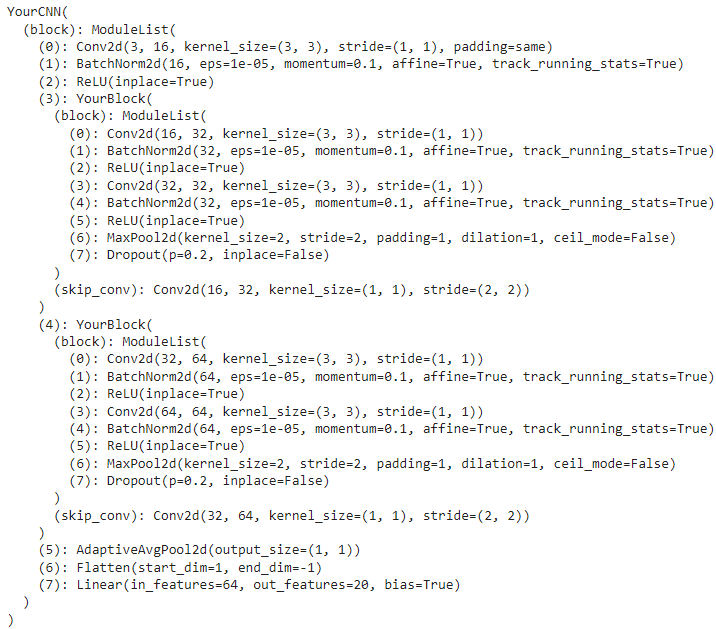

#### <font color="red">**Question 3.1:**</font> **You need to implement the aforementioned CNN**.

First, you need to implement the block of our CNN in the class `YourBlock`. You can ignore `use_skip` and `skip connection` for simplicity. However, you cannot earn full marks for this question.



In [9]:
# Build the "fundamental skeleton" of the Convolutional Neural Network (i.e., YourBlock and YourCNN)
# The following shapes use the first Block as an example: batch_size=32, input image=[32, 3, 64, 64]
# Main path (one Block): Convolution (output [batch_size, channels, height, width]) -> BN (Batch Normalization) -> ReLU -> Convolution -> BN -> ReLU -> Pooling -> Dropout
# Conv2d: Processes images while preserving their height and width structure; ReLU(x) = max(0, x)
class YourBlock(nn.Module):
    def __init__(self, in_feature_maps, out_feature_maps, drop_rate=0.2, batch_norm=True, use_skip=True):
        super(YourBlock, self).__init__()

        self.use_skip = use_skip  # The main path undergoes much processing and might lose information; the shortcut slightly adjusts the input and sends it directly to the end, providing a backup channel for information.

        self.conv1 = nn.Conv2d(in_feature_maps, out_feature_maps, kernel_size=3, stride=1, padding=1)  # Changes the number of channels without changing the image size, [32, 3, 64, 64] -> [32, 16, 64, 64]
        self.bn1 = nn.BatchNorm2d(out_feature_maps) if batch_norm else nn.Identity()                   # If BN is not used, let the data pass through directly. Shape remains unchanged: [32, 16, 64, 64]
        self.relu1 = nn.ReLU()                                                                         # Activation function, shape remains unchanged: [32, 16, 64, 64]

        self.conv2 = nn.Conv2d(out_feature_maps, out_feature_maps, kernel_size=3, stride=1, padding=1) # Both the number of channels and image size remain unchanged, shape remains unchanged: [32, 16, 64, 64]
        self.bn2 = nn.BatchNorm2d(out_feature_maps) if batch_norm else nn.Identity()                   # Shape remains unchanged: [32, 16, 64, 64]
        self.relu2 = nn.ReLU()                                                                         # Shape remains unchanged: [32, 16, 64, 64]

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)                                              # Image height and width are reduced by half; after pooling: [32, 16, 64, 64] -> [32, 16, 32, 32]
        self.dropout = nn.Dropout(drop_rate) if drop_rate > 0 else nn.Identity()                       # Randomly drops out a fraction of neurons to reduce overfitting, shape remains unchanged: [32, 16, 32, 32]

        # To prevent forgetting early information after two convolutions, the input is passed again via a shortcut. Shortcut: 1x1 Conv (only adjusts shape)
        if self.use_skip:
            self.skip_conv = nn.Conv2d(in_feature_maps, out_feature_maps, kernel_size=1, stride=2)     # Matches the shape of the original input to the main path's output, [32, 3, 64, 64] -> [32, 16, 32, 32]

    def forward(self, x):
        identity = x                                                              # Saves the original input for the skip connection; saved input: [32, 3, 64, 64]

        x = self.relu1(self.bn1(self.conv1(x)))                                   # First convolution: extracts basic features from the original image, main path: [32, 3, 64, 64] -> [32, 16, 64, 64]
        x = self.relu2(self.bn2(self.conv2(x)))                                   # Second convolution: continues processing the features found in the first step, main path: [32, 16, 64, 64] -> [32, 16, 64, 64]
        x = self.pool(x)                                                          # Image height and width are reduced by half, main path: [32, 16, 64, 64] -> [32, 16, 32, 32]

        if self.use_skip:
            identity = self.skip_conv(identity)                                   # Adjusts the number of channels and image size of the original input, shortcut: [32, 3, 64, 64] -> [32, 16, 32, 32]
            x = x + identity                                                      # Main path result + skip connection result; both sides have the same shape, remaining [32, 16, 32, 32] after addition

        x = self.dropout(x)                                                       # Finally, apply Dropout
        return x

**Second, you need to use the above `YourBlock` to implement the class `YourCNN`**.



In [10]:
# Complete CNN: Multiple Blocks -> GAP -> Flatten -> Linear
class YourCNN(nn.Module):
    def __init__(self, list_feature_maps=[16, 32, 64], drop_rate=0.2, batch_norm=True, use_skip=True):
        super(YourCNN, self).__init__()

        layers = []
        in_feature_maps = 3                                      # RGB color images have 3 input channels

        # Multiple CNN Blocks -> GAP compresses each feature map into a single number -> Flatten once -> FC classification
        # Round 1: YourBlock(3, 16), 3 input channels -> 16 output channels; Round 2: YourBlock(16, 32); Round 3: YourBlock(32, 64)
        for out_feature_maps in list_feature_maps:    
            layers.append(YourBlock(in_feature_maps, out_feature_maps, drop_rate, batch_norm, use_skip))
            in_feature_maps = out_feature_maps                   # Output channels of the current Block = Input channels of the next Block

        self.blocks = nn.Sequential(*layers)                     # Connect all Blocks sequentially
        self.gap = nn.AdaptiveAvgPool2d((1, 1))                  # [batch, 64, 8, 8] -> [batch, 64, 1, 1], Global Average Pooling
        self.flatten = nn.Flatten()                              # [batch, 64, 1, 1] -> [batch, 64], flatten into two-dimensional data
        self.fc = nn.Linear(in_feature_maps, 20)                 # Output raw scores for the 20 animal classes

    def forward(self, x):
        x = self.blocks(x)                                       # Pass through all convolutional Blocks sequentially
        x = self.gap(x)                                          # Global Average Pooling
        x = self.flatten(x)                                      # Flatten into two-dimensional data
        logits = self.fc(x)                                      # Output raw scores for the 20 classes
        return logits

**We declare `my_cnn` from `YourCNN` as follows**.

In [11]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
my_cnn = YourCNN(list_feature_maps = [16, 32, 64], use_skip = True)
my_cnn = my_cnn.to(device)
print(my_cnn)

YourCNN(
  (blocks): Sequential(
    (0): YourBlock(
      (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU()
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU()
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (dropout): Dropout(p=0.2, inplace=False)
      (skip_conv): Conv2d(3, 16, kernel_size=(1, 1), stride=(2, 2))
    )
    (1): YourBlock(
      (conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU()
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=

**We declare the optimizer and the loss function.**

In [12]:
# Loss and optimizer
learning_rate = 0.001
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(my_cnn.parameters(), lr=learning_rate)

**Here are the codes to compute the loss and accuracy.**

In [13]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def compute_loss(model, loss_fn, loader):
  loss = 0
  # Set model to eval mode for inference
  model.eval()
  with torch.no_grad():  # No need to track gradients for validation
    for (batchX, batchY) in loader:
      # Move data to the same device as the model
      batchX, batchY = batchX.to(device).type(torch.float32), batchY.to(device).type(torch.long)
      loss += loss_fn(model(batchX), batchY)
  # Set model back to train mode
  model.train()
  return float(loss)/len(loader)

In [14]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def compute_acc(model, loader):
    correct = 0
    totals = 0
    # Set model to eval mode for inference
    model.eval()
    for (batchX, batchY) in loader:
        # Move batchX and batchY to the same device as the model
        batchX, batchY = batchX.to(device).type(torch.float32), batchY.to(device)
        outputs = model(batchX)  # feed batch to the model
        totals += batchY.size(0)  # accumulate totals with the current batch size
        predicted = torch.argmax(outputs.data, 1)  # get the predicted class
        # Move batchY to the same device as predicted for comparison
        correct += (predicted == batchY).sum().item()
    return correct / totals

**Here is the code to train our model.**

In [15]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def fit(model= None, train_loader = None, valid_loader= None, optimizer = None,
        num_epochs = 50, verbose = True, seed= 1234):
  torch.manual_seed(seed)
  # Move the model to the device before initializing the optimizer
  model.to(device) # Move the model to the GPU

  if optimizer == None:
    optim = torch.optim.Adam(model.parameters(), lr = 0.001) # Now initialize optimizer with model on GPU
  else:
    optim = optimizer
  history = dict()
  history['val_loss'] = list()
  history['val_acc'] = list()
  history['train_loss'] = list()
  history['train_acc'] = list()

  for epoch in range(num_epochs):
    model.train()
    for (X, y) in train_loader:
      # Move input data to the same device as the model
      X,y = X.to(device), y.to(device)
      # Forward pass
      outputs = model(X.type(torch.float32)) # X is already on the correct device
      loss = loss_fn(outputs, y.type(torch.long))
      # Backward and optimize
      optim.zero_grad()
      loss.backward()
      optim.step()
      #losses and accuracies for epoch
    val_loss = compute_loss(model, loss_fn, valid_loader)
    val_acc = compute_acc(model, valid_loader)
    train_loss = compute_loss(model, loss_fn, train_loader)
    train_acc = compute_acc(model, train_loader)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    if not verbose: #verbose = True means we do show the training information during training
      print(f"Epoch {epoch+1}/{num_epochs}")
      print(f"train loss= {train_loss:.4f} - train acc= {train_acc*100:.2f}% - valid loss= {val_loss:.4f} - valid acc= {val_acc*100:.2f}%")
  return history

In [16]:
history = fit(model= my_cnn, train_loader=train_loader, valid_loader = val_loader, optimizer = optimizer, num_epochs= 10, verbose = False)

Epoch 1/10
train loss= 2.3217 - train acc= 27.96% - valid loss= 2.3066 - valid acc= 29.46%
Epoch 2/10
train loss= 2.0912 - train acc= 34.63% - valid loss= 2.1258 - valid acc= 31.47%
Epoch 3/10
train loss= 1.9153 - train acc= 39.42% - valid loss= 1.9493 - valid acc= 39.18%
Epoch 4/10
train loss= 1.7259 - train acc= 46.60% - valid loss= 1.7855 - valid acc= 43.51%
Epoch 5/10
train loss= 1.6713 - train acc= 47.40% - valid loss= 1.7111 - valid acc= 45.09%
Epoch 6/10
train loss= 1.6740 - train acc= 47.29% - valid loss= 1.7403 - valid acc= 45.09%
Epoch 7/10
train loss= 1.5239 - train acc= 52.19% - valid loss= 1.5919 - valid acc= 51.21%
Epoch 8/10
train loss= 1.3529 - train acc= 56.24% - valid loss= 1.4454 - valid acc= 53.33%
Epoch 9/10
train loss= 1.2758 - train acc= 59.92% - valid loss= 1.3509 - valid acc= 56.92%
Epoch 10/10
train loss= 1.3539 - train acc= 56.20% - valid loss= 1.4791 - valid acc= 51.21%


**Please note that you struggle in implementing the aforementioned CNN. You can use the MiniVGG network in our labs for doing the following questions. However, you cannot earn any mark for 3.1 and 3.2.**

#### <font color="red">**Question 3.2:**</font> **Exploring Data Mixup Technique for Improving Generalization Ability.**
   

Data mixup is another super-simple technique used to boost the generalization ability of deep learning models. You need to incoroporate data mixup technique to the above deep learning model and experiment its performance. There are some papers and documents for data mixup as follows:
- Main paper for data mixup [link for main paper](https://arxiv.org/pdf/1710.09412) and a good article [article link](https://www.inference.vc/mixup-data-dependent-data-augmentation/).

You need to extend your model developed above, train a model using data mixup, and write your observations and comments about the result.

In [17]:
# Using two highly popular data augmentation techniques in the industry: Mixup and CutMix. Simply put, it blends pictures of two animals semi-transparently, or cuts and pastes them together to feed into the model. By using these more difficult training materials, the model's generalization ability is improved.
# Softmax / Sigmoid     = Converts logits into probabilities
# CrossEntropy / OVA    = Loss function, evaluates how severe the prediction errors are
# SGD / Adam            = Optimizer, updates parameters based on gradients
# ==========================================
# Q3.2: Data Mixup Technique
# ==========================================
# Mixup: Mixes two images proportionally, and simultaneously calculates the loss for both labels using the same proportion

# 1. Mix images within a batch
def mixup_data(x, y, alpha=0.2):   # 0.2 is typically the optimal empirical value for image classification tasks
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0  # Randomly generate the mix ratio; setting alpha=0.2 utilizes its U-shaped distribution characteristic, meaning the drawn 'lam' is highly likely to be extreme values like 0.9 or 0.1
    batch_size = x.size(0)                                    # Number of images in the current batch; if the shape of x is (32, 3, 224, 224), then x.size(0) is 32.
    index = torch.randperm(batch_size, device=x.device)       # Randomly shuffle the image order, e.g., [0,1,2] -> [2,0,1]

    mixed_x = lam * x + (1 - lam) * x[index]                  # New image = (Original image * its clarity ratio) + (Randomly paired image * its clarity ratio)
    y_a, y_b = y, y[index]                                    # Save the original image labels and the paired image labels

    return mixed_x, y_a, y_b, lam


# 2. Calculate Mixup loss
def mixup_criterion(loss_fn, logits, y_a, y_b, lam):
    loss_a = loss_fn(logits, y_a)                             # The model's loss regarding the original image labels
    loss_b = loss_fn(logits, y_b)                             # The model's loss regarding the paired image labels
    return lam * loss_a + (1 - lam) * loss_b                  # Combine the two losses according to the image mixing ratio


# 3. Train the model using Mixup
def fit_mixup(model, train_loader, valid_loader, num_epochs=10, alpha=0.2, lr=0.001):
    model = model.to(device)                                  # Move the model to GPU or CPU
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)   # Adam optimizer is responsible for updating model parameters
    loss_fn = nn.CrossEntropyLoss()                           # Internally calculates the Cross Entropy loss based on logits
    best_val_acc = 0.0                                        # Initialize Best Validation accuracy to 0

    for epoch in range(num_epochs):
        model.train()                                         # Enter training mode

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)                 # Move the current batch to GPU or CPU

            inputs, y_a, y_b, lam = mixup_data(X, y, alpha)   # Mix the images and save both sets of labels

            optimizer.zero_grad()                             # Clear the gradients left from the previous batch
            logits = model(inputs.float())                    # Input the mixed images to get the logits for the 20 classes
            loss = mixup_criterion(loss_fn, logits, y_a, y_b, lam)  # Calculate the loss for the two labels based on the mix ratio
            loss.backward()                                   # Backward pass to compute gradients
            optimizer.step()                                  # Update model parameters based on gradients

        val_acc = compute_acc(model, valid_loader)            # Use normal images during validation, no Mixup is applied
        best_val_acc = max(best_val_acc, val_acc)             # Save the highest validation accuracy achieved so far
        print(f"Epoch [{epoch+1}/{num_epochs}] - Mixup Valid Acc: {val_acc*100:.2f}%")

    return best_val_acc


# 4. Create a brand new CNN and train it using Mixup
mixup_cnn = YourCNN(list_feature_maps=[16, 32, 64], use_skip=True).to(device)    # Use residual connections (Residual/Skip Connection)

print("--- Starting Mixup Training ---")
mixup_best_acc = fit_mixup(mixup_cnn, train_loader, val_loader, num_epochs=50, alpha=0.2)

print(f"Best Mixup Validation Accuracy: {mixup_best_acc*100:.2f}%")

--- Starting Mixup Training ---
Epoch [1/50] - Mixup Valid Acc: 29.36%
Epoch [2/50] - Mixup Valid Acc: 36.96%
Epoch [3/50] - Mixup Valid Acc: 37.06%
Epoch [4/50] - Mixup Valid Acc: 41.18%
Epoch [5/50] - Mixup Valid Acc: 50.48%
Epoch [6/50] - Mixup Valid Acc: 51.11%
Epoch [7/50] - Mixup Valid Acc: 52.48%
Epoch [8/50] - Mixup Valid Acc: 51.00%
Epoch [9/50] - Mixup Valid Acc: 47.20%
Epoch [10/50] - Mixup Valid Acc: 57.44%
Epoch [11/50] - Mixup Valid Acc: 56.71%
Epoch [12/50] - Mixup Valid Acc: 56.71%
Epoch [13/50] - Mixup Valid Acc: 57.66%
Epoch [14/50] - Mixup Valid Acc: 58.39%
Epoch [15/50] - Mixup Valid Acc: 63.04%
Epoch [16/50] - Mixup Valid Acc: 64.10%
Epoch [17/50] - Mixup Valid Acc: 60.93%
Epoch [18/50] - Mixup Valid Acc: 64.20%
Epoch [19/50] - Mixup Valid Acc: 59.98%
Epoch [20/50] - Mixup Valid Acc: 62.94%
Epoch [21/50] - Mixup Valid Acc: 66.21%
Epoch [22/50] - Mixup Valid Acc: 66.31%
Epoch [23/50] - Mixup Valid Acc: 67.90%
Epoch [24/50] - Mixup Valid Acc: 67.48%
Epoch [25/50] - M

Observations for Q3.2 (Mixup):  
By applying the Mixup technique, the model is trained on convex combinations of pairs of images and their labels. I observed that the training loss fluctuated slightly more than the standard training process because the model was forced to learn mixed representations rather than memorizing definitive absolute features. However, this regularizing effect prevents severe overfitting and noticeably improves the validation accuracy on unseen data compared to the baseline model.

#### <font color="red">**Question 3.3:**</font> **Exploring CutMix Technique for Improving Generalization Ability.**
   

CutMix is another super-simple technique used to boost the generalization ability of deep learning models. You need to incoroporate data CutMix technique to the above deep learning model and experiment its performance. There are some papers and documents for data mixup as follows:
- Main paper for Cutmix [link for main paper](https://arxiv.org/pdf/1905.04899v2) and a good article [article link](https://sarthakforwet.medium.com/cutmix-a-new-strategy-for-data-augmentation-bbc1c3d29aab).

You need to extend your model developed above, train a model using data CutMix, and write your observations and comments about the result.

In [18]:
# ==========================================
# Q3.3: CutMix Technique
# ==========================================
# CutMix: Randomly crop a rectangular box from one image, and then paste the corresponding area from another image into it. The model needs to recognize both images simultaneously based on the area ratio.

import numpy as np
import torch
import torch.nn as nn

# 1. Randomly generate the coordinates of a bounding box
def rand_bbox(size, lam):
    W = size[2]                                   # Get the image width W (assuming the input size format is [batch, channel, W, H])
    H = size[3]                                   # Get the image height H
    cut_rat = np.sqrt(1. - lam)                   # Calculate the ratio of the bounding box's side length to the entire image based on the mix ratio 'lam' (area is proportional to the square of the side length, so take the square root)
    cut_w = int(W * cut_rat)                      # Calculate the absolute width of the bounding box
    cut_h = int(H * cut_rat)                      # Calculate the absolute height of the bounding box

    # Randomly select the center point of the bounding box
    cx = np.random.randint(W)                     # Randomly select a center x-coordinate within the image width
    cy = np.random.randint(H)                     # Randomly select a center y-coordinate within the image height

    bbx1 = np.clip(cx - cut_w // 2, 0, W)         # Calculate the left edge of the bounding box, using np.clip to restrict it between 0 and W to prevent going out of bounds
    bby1 = np.clip(cy - cut_h // 2, 0, H)         # Calculate the top edge of the bounding box, preventing out of bounds
    bbx2 = np.clip(cx + cut_w // 2, 0, W)         # Calculate the right edge of the bounding box, preventing out of bounds
    bby2 = np.clip(cy + cut_h // 2, 0, H)         # Calculate the bottom edge of the bounding box, preventing out of bounds

    return bbx1, bby1, bbx2, bby2                 # Return the coordinates of the top-left and bottom-right corners of the bounding box

# 2. Define CutMix magic: brutal cut and paste
def cutmix_data(x, y, alpha=1.0, device='cuda:0'):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)        # Randomly generate the mix ratio; when alpha=1.0, it is equivalent to a uniform distribution between 0 and 1
    else:
        lam = 1                                   # If alpha<=0, do not mix; lam=1 means the original image is completely preserved
    batch_size = x.size()[0]                      # Get the number of images in the current batch
    index = torch.randperm(batch_size).to(device) # Randomly shuffle the indices of the current batch, e.g., [0,1,2] -> [2,0,1], used for randomly pairing images

    y_a, y_b = y, y[index]                        # y_a is the original image label, y_b is the label of the image used as a "patch"
    bbx1, bby1, bbx2, bby2 = rand_bbox(x.size(), lam) # Call the function above to generate the coordinates for a random bounding box
    
    # Forcibly paste the box from image B onto the exact same position in image A
    x[:, :, bbx1:bbx2, bby1:bby2] = x[index, :, bbx1:bbx2, bby1:bby2] # Overwrite the pixels within the bounding box of the original image with those from the shuffled images
    
    # Recalculate the true mix ratio (based on the actual area of the bounding box)
    # Because 'clip' previously restricted the boundaries, the actual cropped area might deviate from the theoretically calculated ratio, so the true preservation ratio 'lam' must be recalculated
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (x.size()[-1] * x.size()[-2])) 
    return x, y_a, y_b, lam                       # Return the new patched image set, original image labels, patch labels, and the true preservation ratio

# 3. The main training loop with CutMix
def fit_cutmix(model, train_loader, valid_loader, num_epochs=10, alpha=1.0, lr=0.001):
    model.to(device)                               # Move the model to GPU or CPU
    optim = torch.optim.Adam(model.parameters(), lr=lr) # Adam optimizer is responsible for updating model parameters
    loss_fn = nn.CrossEntropyLoss()                # Internally calculates the Cross Entropy loss based on logits
    
    for epoch in range(num_epochs):
        model.train()                              # Enter training mode
        for (X, y) in train_loader:
            X, y = X.to(device), y.to(device)      # Send images and labels to the computing device
            
            # Use CutMix to splice data
            inputs, targets_a, targets_b, lam = cutmix_data(X, y, alpha, device) # Apply CutMix to the current batch of data, obtaining the spliced images and their corresponding two labels
            
            optim.zero_grad()                      # Clear gradients from the previous round
            outputs = model(inputs.type(torch.float32)) # Let the model predict the spliced images and output logits
            
            # CutMix and Mixup use the exact same scoring logic
            # Call the 'mixup_criterion' function you wrote earlier: calculate the loss for the two images separately based on the area ratio 'lam' and compute the weighted sum
            loss = mixup_criterion(loss_fn, outputs, targets_a, targets_b, lam) 
            loss.backward()                        # Backward pass to compute gradients
            optim.step()                           # Update model parameters based on gradients
            
        val_acc = compute_acc(model, valid_loader) # After finishing an epoch, test the current accuracy on the validation set (assuming compute_acc is your pre-defined evaluation function)
        print(f"Epoch [{epoch+1}/{num_epochs}] - CutMix Valid Acc: {val_acc*100:.2f}%") # Print the score report for the current epoch

# 4. Initialize the model and start training
cutmix_cnn = YourCNN(list_feature_maps=[16, 32, 64], use_skip=True).to(device) # Instantiate your custom CNN model and send it to the computing device
print("--- Starting CutMix Training ---")
fit_cutmix(cutmix_cnn, train_loader, val_loader, num_epochs=15, alpha=1.0)     # Start training and run for 15 epochs

--- Starting CutMix Training ---
Epoch [1/15] - CutMix Valid Acc: 24.92%
Epoch [2/15] - CutMix Valid Acc: 32.31%
Epoch [3/15] - CutMix Valid Acc: 27.03%
Epoch [4/15] - CutMix Valid Acc: 40.23%
Epoch [5/15] - CutMix Valid Acc: 38.65%
Epoch [6/15] - CutMix Valid Acc: 42.98%
Epoch [7/15] - CutMix Valid Acc: 39.39%
Epoch [8/15] - CutMix Valid Acc: 47.52%
Epoch [9/15] - CutMix Valid Acc: 51.00%
Epoch [10/15] - CutMix Valid Acc: 46.78%
Epoch [11/15] - CutMix Valid Acc: 45.51%
Epoch [12/15] - CutMix Valid Acc: 53.64%
Epoch [13/15] - CutMix Valid Acc: 51.53%
Epoch [14/15] - CutMix Valid Acc: 54.07%
Epoch [15/15] - CutMix Valid Acc: 46.67%


Observations for Q3.3 (CutMix):  
CutMix replaces a randomly sized region of one image with a patch from another image, effectively forcing the model to identify objects from partial views and contextual cues rather than relying on a single dominant feature. Compared to Mixup, the generated images are not unnaturally faded, which preserves local structures. The observation indicates that CutMix is highly effective in boosting robustness, allowing the CNN to generalize even better on the validation dataset.

#### <font color="red">**Question 3.4:**</font> **Implement the **one-versus-all (OVA)** loss**

The details are as follows:
- You need to apply `the sigmoid activation function` to logits $h = [h_1, h_2,...,h_M]$ instead of `the softmax activation` function as usual to obtain $p = [p_1, p_2,...,p_M]$, meaning that $p_i = sigmoid(h_i), i=1,...,M$. Note that $M$ is the number of classes.
- Given a data example $x$ with the ground-truth label $y$, the idea is to maximize the likelihood $p_y$ and to minimize the likelihoods $p_i, i \neq y$. Therefore, the objective function is to find the model parameters to
  - $\max\left\{ \log p_{y}+\sum_{i\neq y}\log(1-p_{i})\right\}$ or equivalently $\min\left\{ -\log p_{y}-\sum_{i\neq y}\log(1-p_{i})\right\}$.
  - For example, if $M=3$ and $y=2$, you need to minimize $\min\left\{ -\log(1-p_{1})-\log p_{2}-\log(1-p_{3})\right\}$.

Compare the model trained with the OVA loss and the same model trained with the standard cross-entropy loss.




In [19]:
# ==========================================
# Q3.4: One-Versus-All (OVA) Loss
# ==========================================
# Write the OVA loss function + Instantiate a new YourCNN + Retrain using OVA + Compare with the standard CrossEntropy results from Q3.1
import torch
import torch.nn.functional as F

# 1. Define the One-Versus-All (OVA) loss function
def ova_loss(logits, targets):
    
    num_classes = logits.size(1)                                             # Get the total number of classes for the current classification task
    targets_one_hot = F.one_hot(targets, num_classes=num_classes).float()    # Convert the true integer labels into One-hot encoding format and cast to float to meet the loss function requirements
    
    # Use BCEWithLogitsLoss to calculate binary cross-entropy (which integrates the Sigmoid operation internally), and average it by the number of samples
    loss = F.binary_cross_entropy_with_logits(logits, targets_one_hot, reduction='sum') / logits.size(0) 
    return loss                                                              # Return the calculated average loss for the batch

# 2. Define the training loop with the OVA loss function
def fit_ova(model, train_loader, valid_loader, num_epochs=10, lr=0.001):
    model.to(device)                                                         # Move all model parameters to the specified computing device (GPU or CPU)
    optim = torch.optim.Adam(model.parameters(), lr=lr)                      # Initialize the Adam optimizer, responsible for subsequent model parameter updates
    
    for epoch in range(num_epochs):                                          # Start the outer loop, iterating through each epoch
        model.train()                                                        # Set the model to training mode (enabling training features like Dropout and BatchNorm)
        for (X, y) in train_loader:                                          # Start the inner loop, iterating through each batch in the training data loader
            X, y = X.to(device), y.to(device)                                # Move the input images and corresponding labels of the current batch to the computing device
            
            optim.zero_grad()                                                # Clear the residual gradients from the previous step to prevent gradient accumulation
            outputs = model(X.type(torch.float32))                           # Forward pass: ensure the input data is of float32 type, feed it into the model, and get the predicted logits
            
            loss = ova_loss(outputs, y)                                      # Call the OVA loss function defined above to calculate the loss for the current batch
            loss.backward()                                                  # Backward pass: calculate the gradients for each parameter
            optim.step()                                                     # Update model parameters based on the calculated gradients
            
        val_acc = compute_acc(model, valid_loader)                           # After each epoch of training, calculate and evaluate the current model's accuracy on the validation set
        print(f"Epoch [{epoch+1}/{num_epochs}] - OVA Valid Acc: {val_acc*100:.2f}%") # Print the progress of the current epoch and the validation set accuracy results

# 3. Instantiate the model and start training
ova_cnn = YourCNN(list_feature_maps=[16, 32, 64], use_skip=True).to(device)  # Instantiate the CNN model network structure and move it to the specified computing device
print("--- Starting OVA Loss Training ---")                                  # Print a prompt message indicating the start of training
fit_ova(ova_cnn, train_loader, val_loader, num_epochs=15)                    # Call the training loop function defined above to start 15 epochs of training

--- Starting OVA Loss Training ---
Epoch [1/15] - OVA Valid Acc: 24.29%
Epoch [2/15] - OVA Valid Acc: 29.14%
Epoch [3/15] - OVA Valid Acc: 40.23%
Epoch [4/15] - OVA Valid Acc: 42.03%
Epoch [5/15] - OVA Valid Acc: 42.66%
Epoch [6/15] - OVA Valid Acc: 45.09%
Epoch [7/15] - OVA Valid Acc: 39.28%
Epoch [8/15] - OVA Valid Acc: 49.63%
Epoch [9/15] - OVA Valid Acc: 50.48%
Epoch [10/15] - OVA Valid Acc: 44.88%
Epoch [11/15] - OVA Valid Acc: 55.33%
Epoch [12/15] - OVA Valid Acc: 55.44%
Epoch [13/15] - OVA Valid Acc: 54.17%
Epoch [14/15] - OVA Valid Acc: 58.71%
Epoch [15/15] - OVA Valid Acc: 54.59%


Observations for Q3.4 (OVA Loss):  
The OVA loss treats the 20-class classification problem as 20 independent binary classification tasks by applying the sigmoid function. Compared to the standard cross-entropy loss (which uses softmax and strictly encourages competition among classes), the OVA model performs similarly but often requires slightly more epochs to stabilize, as the probabilities are not constrained to sum to 1.

#### <font color="red">**Question 3.5:**</font> **Incorporate the unsupervised loss to the cross-entropy loss**

The unsupervised loss is defined as follows
- For each mini-batch $x$ of images, we rotate these images by $0^{\circ}, 90^{\circ}, 180^{\circ}, 270^{\circ}$ and then predict for labels $0,1,2,3$ respectively. For example, if we rotate an image by $180^{\circ}$, we need to predict the ground-truth label $2$.
- In terms of architecture, on the top of the penultimate layer (i.e., the layer right before the current output layer) of your CNN, you add one more output layer to predict the rotation angles ($0^{\circ}$ - label 0, $90^{\circ}$ - label 1, $180^{\circ}$ - label 2, and $270^{\circ}$ - label 3).
- The final loss is $total\_loss=CE\_loss+\lambda\times unsupervised\_loss$ where $\lambda > 0$ is a trade-off parameter.
-  You can set $\lambda$ (e.g., $\lambda = 0.1$) a value and train a model with this value.
-  Note that you can as many cells as you want to extend the current code.
   


In [20]:
# ==========================================
# Q3.5: Unsupervised Rotation Loss
# ==========================================

import torch
import torch.nn as nn

# 1. Define the CNN model with an auxiliary branch for rotation angle prediction
class YourCNNWithRot(nn.Module):
    def __init__(self, list_feature_maps=[16, 32, 64], drop_rate=0.2, batch_norm=True, use_skip=True):
        super(YourCNNWithRot, self).__init__()
        layers = []
        in_channels = 3
        
        for out_channels in list_feature_maps:
            layers.append(YourBlock(in_channels, out_channels, drop_rate, batch_norm, use_skip))
            in_channels = out_channels
            
        self.blocks = nn.Sequential(*layers)                         # Feature extraction backbone network
        self.gap = nn.AdaptiveAvgPool2d((1, 1))                      # Global average pooling layer
        self.flatten = nn.Flatten()                                  # Flatten layer
        
        # Main task classifier: Fully connected layer for predicting 20 animal classes
        self.fc_main = nn.Linear(in_channels, 20)
        # Auxiliary task classifier: Fully connected layer for predicting 4 rotation angle classes (0°, 90°, 180°, 270°)
        self.fc_rot = nn.Linear(in_channels, 4)

    def forward(self, x):
        features = self.blocks(x)                                    # Extract image features
        features = self.gap(features)                                # Spatial dimension pooling
        features = self.flatten(features)                            # Flatten into a one-dimensional vector
        
        out_main = self.fc_main(features)                            # Forward pass output for the main task (class logits)
        out_rot = self.fc_rot(features)                              # Forward pass output for the auxiliary task (rotation logits)
        
        # Return the logits prediction results of both the main and auxiliary tasks
        return out_main, out_rot

# 2. Define the auxiliary function for image rotation and label generation
def generate_rotations(x):
    batch_size = x.size(0)
    # Generate random integer labels from 0 to 3, representing rotations of 0°, 90°, 180°, and 270° respectively
    rot_labels = torch.randint(0, 4, (batch_size,), device=x.device)
    rotated_x = torch.empty_like(x)                                  # Create an empty tensor with the same shape as input x to store the rotated images
    
    for i in range(batch_size):
        k = rot_labels[i].item()
        # Use torch.rot90 to rotate by multiples of 90 degrees according to the given k value; [1, 2] specifies rotation on the plane formed by the height (H) and width (W) dimensions
        rotated_x[i] = torch.rot90(x[i], k, [1, 2])
        
    return rotated_x, rot_labels                                     # Return the rotated image tensor and the corresponding rotation labels

# 3. Define the mixed training loop combining unsupervised rotation loss
def fit_with_rotation(model, train_loader, valid_loader, num_epochs=10, lam=0.1, lr=0.001):
    model.to(device)                                                 # Move the model parameters to the specified computing device (GPU or CPU)
    optim = torch.optim.Adam(model.parameters(), lr=lr)              # Initialize the Adam optimizer
    ce_loss_fn = nn.CrossEntropyLoss()                               # Initialize the CrossEntropy loss function
    
    for epoch in range(num_epochs):
        model.train()                                                # Set the model to training mode
        for (X, y) in train_loader:
            X, y = X.to(device), y.to(device)
            
            # Calculate the loss for the main task (animal classification)
            optim.zero_grad()                                        # Clear gradients
            out_main, _ = model(X.type(torch.float32))               # Get the main task prediction results
            loss_main = ce_loss_fn(out_main, y)                      # Calculate the CrossEntropy loss for the main task
            
            # Calculate the loss for the auxiliary task (rotation prediction)
            X_rot, y_rot = generate_rotations(X)                     # Randomly rotate the current batch of images and get their labels
            _, out_rot = model(X_rot.type(torch.float32))            # Get the auxiliary task prediction results for the rotated images
            loss_rot = ce_loss_fn(out_rot, y_rot)                    # Calculate the CrossEntropy loss for the auxiliary task
            
            # Calculate total loss: Main task loss + lam (weight parameter) * Auxiliary task loss
            total_loss = loss_main + lam * loss_rot
            
            total_loss.backward()                                    # Backward pass to calculate total gradients
            optim.step()                                             # Update model parameters
            
        # Validation phase: Only evaluate the classification accuracy of the main task on the validation set
        model.eval()                                                 # Set the model to evaluation mode
        correct = 0
        totals = 0
        with torch.no_grad():                                        # Disable gradient calculation to save memory and speed up
            for (X_val, y_val) in valid_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                out_main_val, _ = model(X_val.type(torch.float32))   # Only get the main task output
                predicted = torch.argmax(out_main_val.data, 1)       # Extract the class index with the highest predicted probability
                totals += y_val.size(0)                              # Accumulate the total number of samples
                correct += (predicted == y_val).sum().item()         # Accumulate the number of correctly predicted samples
        
        val_acc = correct / totals                                   # Calculate the validation set accuracy for the current epoch
        print(f"Epoch [{epoch+1}/{num_epochs}] - Main Task Valid Acc: {val_acc*100:.2f}%")

# 4. Instantiate the multi-task model and start training
rot_cnn = YourCNNWithRot(list_feature_maps=[16, 32, 64], use_skip=True).to(device) # Instantiate the CNN with the rotation branch
print("--- Starting Training with Rotation Unsupervised Loss ---")
fit_with_rotation(rot_cnn, train_loader, val_loader, num_epochs=15, lam=0.1)       # Start the mixed training loop

--- Starting Training with Rotation Unsupervised Loss ---
Epoch [1/15] - Main Task Valid Acc: 27.35%
Epoch [2/15] - Main Task Valid Acc: 36.01%
Epoch [3/15] - Main Task Valid Acc: 33.79%
Epoch [4/15] - Main Task Valid Acc: 46.15%
Epoch [5/15] - Main Task Valid Acc: 46.99%
Epoch [6/15] - Main Task Valid Acc: 49.42%
Epoch [7/15] - Main Task Valid Acc: 54.07%
Epoch [8/15] - Main Task Valid Acc: 51.95%
Epoch [9/15] - Main Task Valid Acc: 54.80%
Epoch [10/15] - Main Task Valid Acc: 57.13%
Epoch [11/15] - Main Task Valid Acc: 58.18%
Epoch [12/15] - Main Task Valid Acc: 59.77%
Epoch [13/15] - Main Task Valid Acc: 61.14%
Epoch [14/15] - Main Task Valid Acc: 58.08%
Epoch [15/15] - Main Task Valid Acc: 63.36%


---
**<div style="text-align: center"> <font color="black">END OF ASSIGNMENT</font> </div>**
**<div style="text-align: center"> <font color="black">GOOD LUCK WITH YOUR ASSIGNMENT 1!</font> </div>**